In [19]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import librosa
import tensorflow as tf
import warnings
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, log_loss, top_k_accuracy_score
)
warnings.filterwarnings("ignore")
 
# Configuration
 
EMOTIONS    = ["angry", "happy", "sad"]
IMG_SIZE    = (48, 48)
SAMPLE_RATE = 22050
DURATION    = 3.0
N_MFCC      = 13
EVAL_PAIRS  = 500
 
# Load models + weights
 
cnn     = tf.keras.models.load_model("1_CNN_model.h5")
svm     = joblib.load("2_SVM_model.pkl")
scaler  = joblib.load("scaler.pkl")
weights = joblib.load("3_Combined_model.pkl")
 
W_CNN = weights["w_cnn"]
W_SVM = weights["w_svm"]
 

In [20]:
def extract_audio_features(path):
    audio, _ = librosa.load(path, sr=SAMPLE_RATE, duration=DURATION, mono=True)
    target   = int(SAMPLE_RATE * DURATION)
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    mfccs  = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
    pitch  = librosa.yin(audio, fmin=librosa.note_to_hz("C2"),
                          fmax=librosa.note_to_hz("C7"))
    energy = librosa.feature.rms(y=audio)
    return np.append(np.mean(mfccs, axis=1), [np.mean(pitch), np.mean(energy)])

In [21]:
def predict_cnn(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    return cnn.predict(arr, verbose=0)[0]   # (3,) softmax probs
 
 
def predict_svm(audio_path):
    feats  = extract_audio_features(audio_path)
    scaled = scaler.transform([feats])
    probs  = svm.predict_proba(scaled)[0]
    order  = list(svm.classes_)
    return np.array([probs[order.index(em)] for em in EMOTIONS])

In [22]:
def predict(audio_path, image_path):
    cnn_probs  = predict_cnn(image_path)
    svm_probs  = predict_svm(audio_path)
    combined   = W_CNN * cnn_probs + W_SVM * svm_probs
    prediction = EMOTIONS[np.argmax(combined)]
    confidence = float(np.max(combined))
 
    return {
        "cnn_probs":      cnn_probs,
        "svm_probs":      svm_probs,
        "combined_probs": combined,
        "prediction":     prediction,
        "confidence":     confidence,
    }

In [23]:
# Visualisation
 
def plot_prediction(result, audio_path, image_path):
    BG     = "#0f0f11"
    PANEL  = "#1a1a22"
    COLORS = ["#e07a4f", "#4fbe94", "#7a7fe0"]   # angry, happy, sad
 
    fig = plt.figure(figsize=(12, 4.5), facecolor=BG)
    fig.suptitle(
        f"Prediction:  {result['prediction'].upper()}   "
        f"({result['confidence']*100:.1f}% confidence)",
        color="white", fontsize=14, fontweight="bold", y=0.97
    )
 
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)
    titles = [
        f"SVM  — audio\n(weight: {W_SVM:.2f})",
        f"CNN  — image\n(weight: {W_CNN:.2f})",
        "Combined"
    ]
    keys = ["svm_probs", "cnn_probs", "combined_probs"]
 
    for col, (title, key) in enumerate(zip(titles, keys)):
        ax = fig.add_subplot(gs[col])
        ax.set_facecolor(PANEL)
        for spine in ax.spines.values():
            spine.set_edgecolor("#333344")
        ax.tick_params(colors="#aaaabb", labelsize=9)
        ax.grid(color="#2a2a38", linewidth=0.5, linestyle="--", axis="x")
 
        probs    = result[key]
        best_idx = np.argmax(probs)
        bar_colors = [
            COLORS[i] if i == best_idx else COLORS[i] + "66"
            for i in range(len(EMOTIONS))
        ]
 
        bars = ax.barh(EMOTIONS, probs, color=bar_colors,
                       edgecolor="#333344", linewidth=0.5, height=0.5)
 
        for bar, prob in zip(bars, probs):
            ax.text(min(prob + 0.02, 0.97),
                    bar.get_y() + bar.get_height() / 2,
                    f"{prob*100:.1f}%",
                    va="center", ha="left", color="white", fontsize=9)
 
        ax.set_xlim(0, 1.18)
        ax.set_xlabel("Probability", color="#aaaabb", fontsize=9)
        ax.set_title(title, color="white", fontsize=10, pad=8)
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%")
        )
        ax.invert_yaxis()
 
    fig.text(0.5, 0.01,
             f"Audio: {audio_path}   |   Image: {image_path}",
             ha="center", color="#555566", fontsize=7.5)
 
    plt.savefig("prediction_result.png", dpi=180,
                bbox_inches="tight", facecolor=BG)
    plt.show()
    print("Saved → prediction_result.png")
 


SVM  probs : {'angry': '73.5%', 'happy': '26.4%', 'sad': '0.0%'}
CNN  probs : {'angry': '35.7%', 'happy': '1.1%', 'sad': '63.2%'}
Combined   : {'angry': '53.9%', 'happy': '13.3%', 'sad': '32.9%'}

Prediction : ANGRY
Confidence : 53.9%


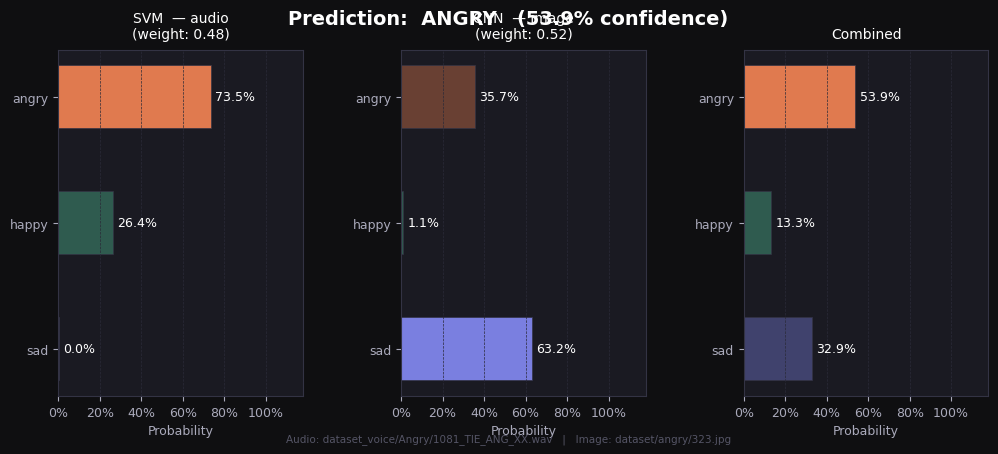

Saved → prediction_result.png


In [24]:

# Run
 
if __name__ == "__main__":
 
    # FILE PATH NAME
    AUDIO_FILE = "dataset_voice/Angry/1081_TIE_ANG_XX.wav"
    IMAGE_FILE = "dataset/angry/323.jpg"
    # FILE PATH NAME
 
    result = predict(AUDIO_FILE, IMAGE_FILE)
 
    print(f"\nSVM  probs : { {em: f'{p*100:.1f}%' for em, p in zip(EMOTIONS, result['svm_probs'])} }")
    print(f"CNN  probs : { {em: f'{p*100:.1f}%' for em, p in zip(EMOTIONS, result['cnn_probs'])} }")
    print(f"Combined   : { {em: f'{p*100:.1f}%' for em, p in zip(EMOTIONS, result['combined_probs'])} }")
    print(f"\nPrediction : {result['prediction'].upper()}")
    print(f"Confidence : {result['confidence']*100:.1f}%")
 
    plot_prediction(result, AUDIO_FILE, IMAGE_FILE)

In [25]:
def plot_all(single_result, stats_cnn, stats_svm, stats_fused,
             audio_path, image_path):
    BG     = "#ffffff"  # White background
    PANEL  = "#ffffff"  # Panel background also white
    COLORS = ["#e07a4f", "#4fbe94", "#7a7fe0"]
    EM_C   = dict(zip(EMOTIONS, COLORS))
    TEXT_COLOR = "#000000"  # Dark text color

    fig = plt.figure(figsize=(16, 11), facecolor=BG)
    fig.suptitle(
        f"Emotion Fusion — Full Report\n"
        f"Prediction: {single_result['prediction'].upper()}  "
        f"({single_result['confidence']*100:.1f}% confidence)",
        color=TEXT_COLOR, fontsize=13, fontweight="bold", y=0.98
    )

    gs_outer = gridspec.GridSpec(3, 1, figure=fig,
                                 hspace=0.55,
                                 top=0.93, bottom=0.05)

    # ── Row 1: single prediction bars ─────────────────────────────────────────
    gs1 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[0], wspace=0.4)
    titles = [f"SVM  (w={W_SVM:.2f})", f"CNN  (w={W_CNN:.2f})", "Combined"]
    keys   = ["svm_probs", "cnn_probs", "combined_probs"]

    for col, (title, key) in enumerate(zip(titles, keys)):
        ax = fig.add_subplot(gs1[col])
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values():
            sp.set_edgecolor(TEXT_COLOR)
        ax.tick_params(colors=TEXT_COLOR, labelsize=8)
        ax.grid(color="#2a2a38", lw=0.5, linestyle="--", axis="x")

        probs    = single_result[key]
        best_idx = np.argmax(probs)
        bcolors  = [COLORS[i] if i == best_idx else COLORS[i] + "55" for i in range(3)]
        bars = ax.barh(EMOTIONS, probs, color=bcolors, edgecolor=TEXT_COLOR, lw=0.5, height=0.5)
        for bar, prob in zip(bars, probs):
            ax.text(min(prob + 0.02, 0.97),
                    bar.get_y() + bar.get_height() / 2,
                    f"{prob*100:.1f}%", va="center", ha="left",
                    color=TEXT_COLOR, fontsize=8)
        ax.set_xlim(0, 1.2)
        ax.set_xlabel("Probability", color=TEXT_COLOR, fontsize=8)
        ax.set_title(title, color=TEXT_COLOR, fontsize=9, pad=6)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v*100:.0f}%"))
        ax.invert_yaxis()

    # ── Row 2: overall accuracy + ROC-AUC + log loss comparison ───────────────
    gs2 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[1], wspace=0.4)
    all_stats = [stats_svm, stats_cnn, stats_fused]
    model_names = ["SVM", "CNN", "Fused"]
    model_colors = ["#4fa3e0", "#e07a4f", "#4fbe94"]

    metrics = [
        ("Overall accuracy (%)", lambda s: s["accuracy"] * 100,      True),
        ("ROC-AUC (macro)",      lambda s: s["roc_auc"],              True),
        ("Log loss",             lambda s: s["log_loss"],             False),
    ]

    for col, (metric_name, fn, higher_better) in enumerate(metrics):
        ax = fig.add_subplot(gs2[col])
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values():
            sp.set_edgecolor(TEXT_COLOR)
        ax.tick_params(colors=TEXT_COLOR, labelsize=8)
        ax.grid(color="#2a2a38", lw=0.5, linestyle="--", axis="y")
        vals = [fn(s) for s in all_stats]
        best = np.argmax(vals) if higher_better else np.argmin(vals)
        bcolors = [model_colors[i] if i == best else model_colors[i] + "66" for i in range(3)]
        bars = ax.bar(model_names, vals, color=bcolors, edgecolor=TEXT_COLOR, lw=0.5, width=0.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals) * 0.02,
                    f"{val:.3f}", ha="center", va="bottom",
                    color=TEXT_COLOR, fontsize=8)
        ax.set_title(metric_name, color=TEXT_COLOR, fontsize=9, pad=6)
        ax.set_ylim(0, max(vals) * 1.2)
        ax.tick_params(axis="x", colors=TEXT_COLOR)

    # ── Row 3: per-class accuracy for each model ───────────────────────────────
    gs3 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[2], wspace=0.4)

    for col, (st, mname) in enumerate(zip(all_stats, model_names)):
        ax = fig.add_subplot(gs3[col])
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values():
            sp.set_edgecolor(TEXT_COLOR)
        ax.tick_params(colors=TEXT_COLOR, labelsize=8)
        ax.grid(color="#2a2a38", lw=0.5, linestyle="--", axis="x")

        accs   = [st["per_class_acc"][em] for em in EMOTIONS]
        bcolors = [EM_C[em] for em in EMOTIONS]
        bars   = ax.barh(EMOTIONS, accs, color=bcolors, edgecolor=TEXT_COLOR, lw=0.5, height=0.5)
        for bar, acc in zip(bars, accs):
            ax.text(min(acc + 0.02, 0.97),
                    bar.get_y() + bar.get_height() / 2,
                    f"{acc*100:.1f}%", va="center", ha="left",
                    color=TEXT_COLOR, fontsize=8)
        ax.set_xlim(0, 1.2)
        ax.set_xlabel("Accuracy", color=TEXT_COLOR, fontsize=8)
        ax.set_title(f"{mname} — per-class accuracy", color=TEXT_COLOR, fontsize=9, pad=6)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v*100:.0f}%"))
        ax.invert_yaxis()

    fig.text(0.5, 0.01,
             f"Audio: {audio_path}   |   Image: {image_path}   |   "
             f"Eval pairs per class: {EVAL_PAIRS}",
             ha="center", color=TEXT_COLOR, fontsize=7)

    plt.savefig("full_report.png", dpi=180, bbox_inches="tight", facecolor=BG)
    plt.show()
    print("\nSaved → full_report.png")

In [26]:
def build_eval_set(image_dir, audio_dir, n=EVAL_PAIRS):
    cnn_probs, svm_probs, labels = [], [], []
    for emotion in EMOTIONS:
        img_files   = [f for f in os.listdir(os.path.join(image_dir, emotion))
                       if f.lower().endswith((".jpg", ".png"))]
        audio_files = [f for f in os.listdir(os.path.join(audio_dir, emotion.capitalize()))
                       if f.lower().endswith((".wav", ".mp3", ".flac"))]
        pairs = min(n, len(img_files), len(audio_files))
        img_sample   = random.sample(img_files, pairs)
        audio_sample = random.sample(audio_files, pairs)
        for img_f, aud_f in zip(img_sample, audio_sample):
            cnn_probs.append(predict_cnn(os.path.join(image_dir, emotion, img_f)))
            svm_probs.append(predict_svm(os.path.join(audio_dir, emotion.capitalize(), aud_f)))
            labels.append(emotion)
    return np.array(cnn_probs), np.array(svm_probs), labels

def compute_stats(probs, labels, name):
    preds = [EMOTIONS[i] for i in np.argmax(probs, axis=1)]
    label_idx = [EMOTIONS.index(l) for l in labels]
    return {
        "name":          name,
        "accuracy":      accuracy_score(labels, preds),
        "roc_auc":       roc_auc_score(label_idx, probs, multi_class="ovr"),
        "log_loss":      log_loss(label_idx, probs),
        "per_class_acc": {em: accuracy_score(
                              [l for l in labels if l == em],
                              [p for p, l in zip(preds, labels) if l == em])
                          for em in EMOTIONS}
    }

def print_stats(s):
    print(f"\n{s['name']}")
    print(f"  Accuracy : {s['accuracy']*100:.1f}%")
    print(f"  ROC-AUC  : {s['roc_auc']:.4f}")
    print(f"  Log Loss : {s['log_loss']:.4f}")
    for em, acc in s['per_class_acc'].items():
        print(f"  {em:<8}: {acc*100:.1f}%")

Running single prediction...
  SVM  : {'angry': '90.5%', 'happy': '9.4%', 'sad': '0.1%'}
  CNN  : {'angry': '4.8%', 'happy': '93.3%', 'sad': '1.9%'}
  Fused: {'angry': '45.9%', 'happy': '53.1%', 'sad': '1.0%'}

  → Prediction : HAPPY
  → Confidence : 53.1%

Building evaluation set (500 pairs per class)...

CNN  (image model)
  Accuracy : 86.1%
  ROC-AUC  : 0.9659
  Log Loss : 0.3399
  angry   : 81.6%
  happy   : 91.8%
  sad     : 84.8%

SVM  (audio model)
  Accuracy : 86.7%
  ROC-AUC  : 0.9636
  Log Loss : 0.3518
  angry   : 86.4%
  happy   : 80.4%
  sad     : 93.2%

Fused  (CNN×0.52 + SVM×0.48)
  Accuracy : 97.0%
  ROC-AUC  : 0.9960
  Log Loss : 0.2749
  angry   : 94.4%
  happy   : 97.8%
  sad     : 98.8%

════════════════════════════════════════════════════
  SUMMARY COMPARISON
════════════════════════════════════════════════════
  Model                  Accuracy    ROC-AUC   Log Loss
  --------------------------------------------------
  CNN  (image model)        86.1%     0.9659   

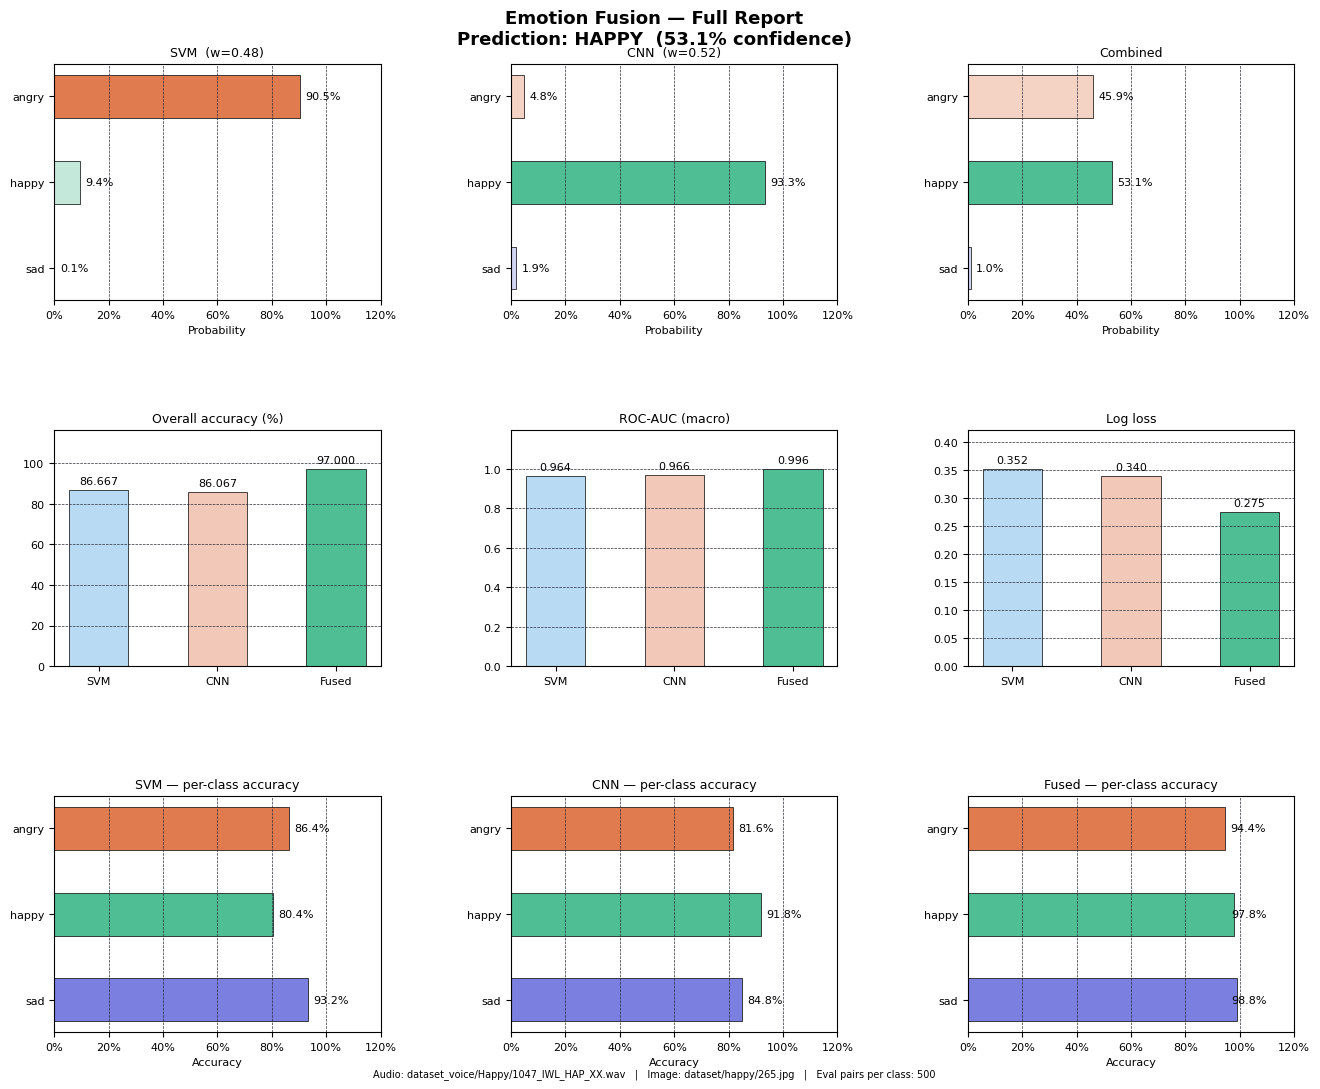


Saved → full_report.png


In [27]:
# ─── RUN ──────────────────────────────────────────────────────────────────────
 
if __name__ == "__main__":
 
    # ── Edit these four lines ─────────────────────────────────────────────────
    AUDIO_FILE = "dataset_voice/Happy/1047_IWL_HAP_XX.wav"
    IMAGE_FILE = "dataset/happy/265.jpg"
    IMAGE_DIR  = "dataset"        # root folder with angry/ happy/ sad/ subfolders
    AUDIO_DIR  = "dataset_voice"  # root folder with angry/ happy/ sad/ subfolders
    # ─────────────────────────────────────────────────────────────────────────
 
    # Single prediction
    print("Running single prediction...")
    result = predict(AUDIO_FILE, IMAGE_FILE)
    print(f"  SVM  : { {em: f'{p*100:.1f}%' for em, p in zip(EMOTIONS, result['svm_probs'])} }")
    print(f"  CNN  : { {em: f'{p*100:.1f}%' for em, p in zip(EMOTIONS, result['cnn_probs'])} }")
    print(f"  Fused: { {em: f'{p*100:.1f}%' for em, p in zip(EMOTIONS, result['combined_probs'])} }")
    print(f"\n  → Prediction : {result['prediction'].upper()}")
    print(f"  → Confidence : {result['confidence']*100:.1f}%")
 
    # Build evaluation set
    print(f"\nBuilding evaluation set ({EVAL_PAIRS} pairs per class)...")
    cnn_p, svm_p, labels = build_eval_set(IMAGE_DIR, AUDIO_DIR)
    fused_p = W_CNN * cnn_p + W_SVM * svm_p
 
    # Compute stats for all three
    stats_cnn   = compute_stats(cnn_p,   labels, "CNN  (image model)")
    stats_svm   = compute_stats(svm_p,   labels, "SVM  (audio model)")
    stats_fused = compute_stats(fused_p, labels, f"Fused  (CNN×{W_CNN:.2f} + SVM×{W_SVM:.2f})")
 
    # Print to console
    for s in [stats_cnn, stats_svm, stats_fused]:
        print_stats(s)
 
    # Summary comparison
    print(f"\n{'═'*52}")
    print("  SUMMARY COMPARISON")
    print(f"{'═'*52}")
    print(f"  {'Model':<20} {'Accuracy':>10} {'ROC-AUC':>10} {'Log Loss':>10}")
    print(f"  {'-'*50}")
    for s in [stats_cnn, stats_svm, stats_fused]:
        print(f"  {s['name']:<20} {s['accuracy']*100:>9.1f}% "
              f"{s['roc_auc']:>10.4f} {s['log_loss']:>10.4f}")
 
    # Plot
    plot_all(result, stats_cnn, stats_svm, stats_fused, AUDIO_FILE, IMAGE_FILE)
 



